In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data_frame = pd.read_csv("data.csv")

In [3]:
data_frame.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [4]:
data_frame.columns

Index(['number_people', 'date', 'timestamp', 'day_of_week', 'is_weekend',
       'is_holiday', 'temperature', 'is_start_of_semester',
       'is_during_semester', 'month', 'hour'],
      dtype='object')

In [5]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [6]:
data_frame.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


### When we look at the data, it is actually very clean. So we don't need to do any encoding etc. The data types are also very clean.<br> Maybe we can deal with the "date". For example, while there are "day", "month" and "hour" in other columns, there is no "year" at the data

In [7]:
#First, let's convert the "date" column to time "datetime" object

data_frame["date"] = pd.to_datetime(data_frame["date"], utc=True)
print(data_frame.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[ns, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(9)
memory usage: 5.2 M

In [8]:
# Now we can just open a column called "year".
data_frame["year"] = data_frame["date"].dt.year

In [9]:
data_frame.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17,2015
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17,2015
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17,2015
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,71.76,0,0,8,17,2015
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,71.76,0,0,8,17,2015


In [10]:
# now we can delete the "date" column
data_frame.drop("date", axis=1, inplace=True)

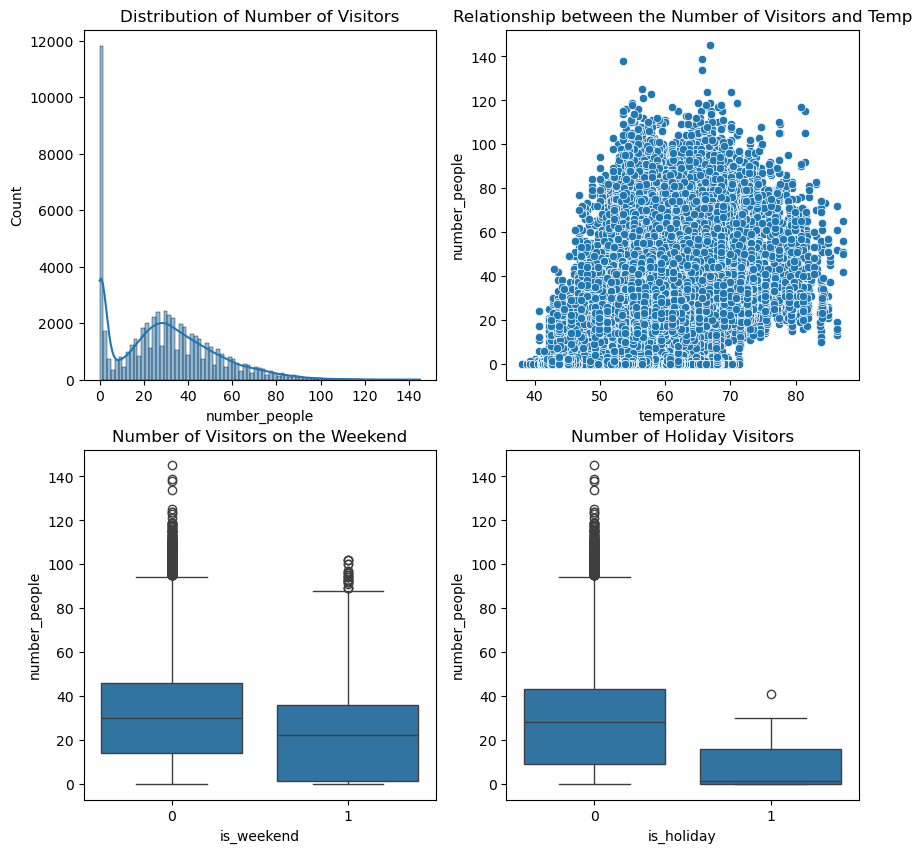

In [11]:

plt.figure(figsize=(10,10))
# Examine the distribution of the 'number_people' column.
plt.subplot(2,2,1)
sns.histplot(data_frame['number_people'], kde=True)
plt.title('Distribution of Number of Visitors')


plt.subplot(2,2,2)
# A scatter plot showing the relationship between 'number_people' and 'temperature'.
sns.scatterplot(x='temperature', y='number_people', data=data_frame)
plt.title('Relationship between the Number of Visitors and Temp')


plt.subplot(2,2,3)
# Examine the relationship between 'number_people' and categorical features such as 'is_weekend' and 'is_holiday' with a box plot.
sns.boxplot(x='is_weekend', y='number_people', data=data_frame)
plt.title('Number of Visitors on the Weekend')


plt.subplot(2,2,4)
sns.boxplot(x='is_holiday', y='number_people', data=data_frame)
plt.title('Number of Holiday Visitors')
plt.show()

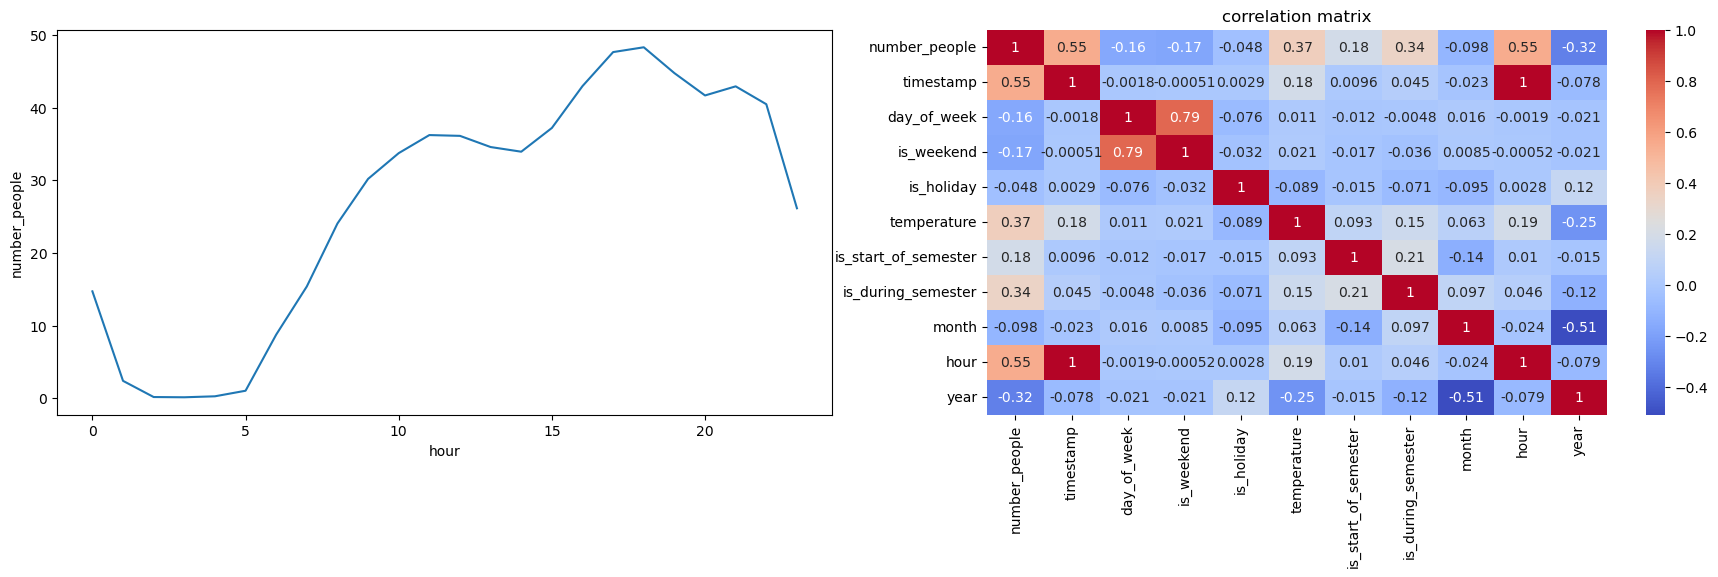

In [12]:
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(22,5))
plt.subplot(1,2,1)
sns.lineplot(data=data_frame, x = "hour", y="number_people", ci=None)

plt.subplot(1,2,2)
sns.heatmap(data_frame.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("correlation matrix")
plt.show()

### There is almost 1 correlation between the "timesamp" and the "hour" column. This is an undesirable situation. Therefore, we can remove the "timestamp" column.

In [13]:
data_frame.drop("timestamp", axis=1, inplace=True)
print(data_frame.head())

   number_people  day_of_week  is_weekend  is_holiday  temperature  \
0             37            4           0           0        71.76   
1             45            4           0           0        71.76   
2             40            4           0           0        71.76   
3             44            4           0           0        71.76   
4             45            4           0           0        71.76   

   is_start_of_semester  is_during_semester  month  hour  year  
0                     0                   0      8    17  2015  
1                     0                   0      8    17  2015  
2                     0                   0      8    17  2015  
3                     0                   0      8    17  2015  
4                     0                   0      8    17  2015  


## Dependent-Independent Features

In [14]:
X = data_frame.drop("number_people", axis=1)
y = data_frame["number_people"]

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Now we will create a function that we can use to compare all the models.

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
def calculate_metrics(test, predict):
    mae = mean_absolute_error(test, predict)
    mse = mean_squared_error(test, predict)
    r2Score = r2_score(test, predict)

    return mae, mse, r2Score

In [19]:
modeller={
    "lineerRegression" : LinearRegression(),
    "lasso" : Lasso(),
    "ridge" : Ridge(),
    "k-neighbors" : KNeighborsRegressor(),
    "decisionTree" : DecisionTreeRegressor(),
    "randomForest" : RandomForestRegressor()
}

In [20]:
for j in range(len(list(modeller))):
    model = list(modeller.values())[j]
    model.fit(X_train, y_train) 

    y_train_pred = model.predict(X_train) #We took this to compare with "test_predict" and examine the "overfitting" situation.
    y_test_pred = model.predict(X_test)

    train_mae, train_mse, train_r2 = calculate_metrics(y_train, y_train_pred)
    test_mae, test_mse, test_r2 = calculate_metrics(y_test, y_test_pred)


    print(list(modeller.values())[j])
    print("evaluation for train set")
    print("mae: ",train_mae)
    print("mse: ",train_mse)
    print("r2_score: ",train_r2)

    print("-*-*-*-*-*-*-*-*-*-*-*-*-")

    print("evaluation for test set")
    print("mae: ",test_mae)
    print("mse: ",test_mse)
    print("r2_score: ",test_r2)
    print("\n-*-*-*-*-*-*-*-*-*-*-*-*-\n")

LinearRegression()
evaluation for train set
mae:  10.733469936454322
mse:  205.1340179448865
r2_score:  0.5999639521710998
-*-*-*-*-*-*-*-*-*-*-*-*-
evaluation for test set
mae:  10.77975237102956
mse:  208.82079130797558
r2_score:  0.5989271376662775

-*-*-*-*-*-*-*-*-*-*-*-*-

Lasso()
evaluation for train set
mae:  10.945189874221992
mse:  212.259326082103
r2_score:  0.5860687429058037
-*-*-*-*-*-*-*-*-*-*-*-*-
evaluation for test set
mae:  10.97059490247691
mse:  216.19324207171786
r2_score:  0.5847671974050243

-*-*-*-*-*-*-*-*-*-*-*-*-

Ridge()
evaluation for train set
mae:  10.7334791788207
mse:  205.13401810651635
r2_score:  0.5999639518559021
-*-*-*-*-*-*-*-*-*-*-*-*-
evaluation for test set
mae:  10.77975955902301
mse:  208.82080363770297
r2_score:  0.5989271139851151

-*-*-*-*-*-*-*-*-*-*-*-*-

KNeighborsRegressor()
evaluation for train set
mae:  3.6420644109953266
mse:  29.360796775161884
r2_score:  0.9427429091444066
-*-*-*-*-*-*-*-*-*-*-*-*-
evaluation for test set
mae:  4

### We got very low scores up to "KNN". For "train" and "test", the scores are close in all of them.

# HyperParameter Tuning

[Click to go to the rrandomForestReg documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)

In [24]:
knn_params = {"n_neighbors" : [2,4,5,6,10,20,30]}

rf_params = {
    "max_depth" : [5,7,8,10,15, None],
    "max_features" : ["sqrt", "log2", 5,6,7,8,None],
    "min_samples_split" : [2,4,8,16,32],
    "n_estimators" : [100,150,200,250,300,350,400,450,500]
}

In [25]:
import warnings
warnings.filterwarnings("ignore")

In [26]:
from sklearn.model_selection import RandomizedSearchCV

randomCv_models = [
    ("knn", KNeighborsRegressor(), knn_params), #just like the "transformer" incident
    ("rf", RandomForestRegressor(), rf_params)
]

for name, model, params in randomCv_models:
    randomCV = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=4, n_jobs=-1)
    randomCV.fit(X_train, y_train)
    print("best params for ", name," is :",randomCV.best_params_ ) 


best params for  knn  is : {'n_neighbors': 2}
best params for  rf  is : {'n_estimators': 250, 'min_samples_split': 4, 'max_features': 6, 'max_depth': None}


In [27]:
models_tuning={
    
    "k-neighbors" : KNeighborsRegressor(n_neighbors=2),
    "randomForest" : RandomForestRegressor(n_estimators=250, min_samples_split=4, max_features=6, max_depth=None)
}



for j in range(len(list(models_tuning))):
    model = list(models_tuning.values())[j]
    model.fit(X_train, y_train) 

    y_train_pred = model.predict(X_train) #We took this to compare with "test_predict" and examine the "overfitting" situation.
    y_test_pred = model.predict(X_test)

    train_mae, train_mse, train_r2 = calculate_metrics(y_train, y_train_pred)
    test_mae, test_mse, test_r2 = calculate_metrics(y_test, y_test_pred)


    print(list(models_tuning.values())[j])
    print("evaluation for train set")
    print("mae: ",train_mae)
    print("mse: ",train_mse)
    print("r2_score: ",train_r2)

    print("-*-*-*-*-*-*-*-*-*-*-*-*-")

    print("evaluation for test set")
    print("mae: ",test_mae)
    print("mse: ",test_mse)
    print("r2_score: ",test_r2)
    print("\n-*-*-*-*-*-*-*-*-*-*-*-*-\n")

KNeighborsRegressor(n_neighbors=2)
evaluation for train set
mae:  3.5543762597023885
mse:  29.81083022428063
r2_score:  0.9418652897023468
-*-*-*-*-*-*-*-*-*-*-*-*-
evaluation for test set
mae:  4.6316737424417855
mse:  47.63064453878811
r2_score:  0.9085179266857696

-*-*-*-*-*-*-*-*-*-*-*-*-

RandomForestRegressor(max_features=6, min_samples_split=4, n_estimators=250)
evaluation for train set
mae:  3.2150453806740207
mse:  22.393048886045385
r2_score:  0.9563308569443625
-*-*-*-*-*-*-*-*-*-*-*-*-
evaluation for test set
mae:  4.295451285848774
mse:  41.1866358174101
r2_score:  0.9208946493607393

-*-*-*-*-*-*-*-*-*-*-*-*-

